<a href="https://colab.research.google.com/github/Ishini01/garment_defect_system/blob/main/MobileNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"

 B105_jpg.rf.0e5bf9a483fd330d150c32d6a63ef2f4.jpg
 B105_jpg.rf.0e5bf9a483fd330d150c32d6a63ef2f4.txt
 B107_jpg.rf.309f6058f107ed8f90d1179136602478.jpg
 B107_jpg.rf.309f6058f107ed8f90d1179136602478.txt
 B10_jpg.rf.0f0b8c9fab27f55abf40b2c1bc8585a9.jpg
 B10_jpg.rf.0f0b8c9fab27f55abf40b2c1bc8585a9.txt
 B111_jpg.rf.7b9c50619b2cca95fb1543f4dc7842b2.jpg
 B111_jpg.rf.7b9c50619b2cca95fb1543f4dc7842b2.txt
 B116_jpg.rf.166898d7d6aebf3292f8d21ef32a0ff2.jpg
 B116_jpg.rf.166898d7d6aebf3292f8d21ef32a0ff2.txt
 B118_jpg.rf.183e9f74eb5d203f6947b0e5962773f5.jpg
 B118_jpg.rf.183e9f74eb5d203f6947b0e5962773f5.txt
 B120_jpg.rf.9110f01b7b7ba217325c0cdb2e7406b3.jpg
 B120_jpg.rf.9110f01b7b7ba217325c0cdb2e7406b3.txt
 B122_jpg.rf.fb00807cc5cf3273174aa8556b7b80d4.jpg
 B122_jpg.rf.fb00807cc5cf3273174aa8556b7b80d4.txt
 B124_jpg.rf.5bab67b9314490a4755a6de51a28da24.jpg
 B124_jpg.rf.5bab67b9314490a4755a6de51a28da24.txt
 B125_jpg.rf.952b1bd6f356d5f3d81c071b5d9046c2.jpg
 B125_jpg.rf.952b1bd6f356d5f3d81c071b5d9046c2.txt
 B

In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches"

In [ ]:
import os
import shutil
import random
from pathlib import Path

from sklearn.model_selection import train_test_split

In [ ]:
import os
import random
import shutil

random.seed(42)

SOURCE_DIR = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches"

BROKEN_DIR = os.path.join(SOURCE_DIR, "broken stitches")
NORMAL_DIR = os.path.join(SOURCE_DIR, "Normal Stitches")

print("Broken stitches:", len(os.listdir(BROKEN_DIR)))
print("Normal stitches:", len(os.listdir(NORMAL_DIR)))

Broken stitches: 1017
Normal stitches: 1395


In [ ]:
# Output directory for the fixed dataset split
SPLIT_DIR = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset"

# Create folders
for split in ["train", "val", "test"]:
    for class_name in ["brokenStitches", "NormalStitches"]:
        os.makedirs(
            os.path.join(SPLIT_DIR, split, class_name),
            exist_ok=True
        )

print("Split folders created.")

Split folders created.


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

dataset_path = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset"

train_path = os.path.join(dataset_path, "train")
validation_path = os.path.join(dataset_path, "validation")
test_path = os.path.join(dataset_path, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

CLASS_NAMES = [
    "Normal Stitches",
    "broken stitches"
]

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=5,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=0.05,
    horizontal_flip=False,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    validation_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=False
)

print("\nClass mapping:", train_generator.class_indices)

print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Test images:", test_generator.samples)

Found 1686 images belonging to 2 classes.
Found 361 images belonging to 2 classes.
Found 364 images belonging to 2 classes.

Class mapping: {'Normal Stitches': 0, 'broken stitches': 1}
Training images: 1686
Validation images: 361
Test images: 364


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=5,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=0.05,
    horizontal_flip=False,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDatasets loaded successfully.")
print("Classes:", CLASS_NAMES)

Found 1686 files belonging to 2 classes.
Found 361 files belonging to 2 classes.
Found 364 files belonging to 2 classes.

Datasets loaded successfully.
Classes: ['Normal Stitches', 'broken stitches']


In [ ]:
class_names = list(train_generator.class_indices.keys())

print("Class names:", class_names)

Class names: ['Normal Stitches', 'broken stitches']


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze MobileNetV2 initially
base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)

output = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,201 (9.87 MB)

 Trainable params: 328,705 (1.25 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

checkpoint_path = (
    "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/"
    "mobilenetv2_broken_stitches_best.keras"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
print("Classes:", train_generator.class_indices)
print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Test images:", test_generator.samples)

Classes: {'Normal Stitches': 0, 'broken stitches': 1}
Training images: 1686
Validation images: 361
Test images: 364


In [ ]:
print("Train generator samples:", train_generator.samples)
print("Validation generator samples:", val_generator.samples)

print("Train generator batches:", len(train_generator))
print("Validation generator batches:", len(val_generator))

print("\nTrain classes:", train_generator.class_indices)
print("Validation classes:", val_generator.class_indices)

print("\nTrain directory:", train_generator.directory)
print("Validation directory:", val_generator.directory)

Train generator samples: 1686
Validation generator samples: 361
Train generator batches: 53
Validation generator batches: 12

Train classes: {'Normal Stitches': 0, 'broken stitches': 1}
Validation classes: {'Normal Stitches': 0, 'broken stitches': 1}

Train directory: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/train
Validation directory: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/validation


In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset"

train_path = os.path.join(
    dataset_path,
    "train"
)

validation_path = os.path.join(
    dataset_path,
    "validation"
)

test_path = os.path.join(
    dataset_path,
    "test"
)

print("Train:", train_path)
print("Validation:", validation_path)
print("Test:", test_path)

Train: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/train
Validation: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/validation
Test: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/test


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["Normal Stitches", "broken stitches"],
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    validation_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["Normal Stitches", "broken stitches"],
    shuffle=False
)

Found 1686 images belonging to 2 classes.
Found 361 images belonging to 2 classes.


In [ ]:
print(train_generator.class_indices)
print(val_generator.class_indices)

{'Normal Stitches': 0, 'broken stitches': 1}
{'Normal Stitches': 0, 'broken stitches': 1}


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.6794 - loss: 0.6023 - precision: 0.6127 - recall: 0.6435
Epoch 1: val_accuracy improved from None to 0.88366, saving model to /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/mobilenetv2_broken_stitches_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/mobilenetv2_broken_stitches_best.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 427ms/step - accuracy: 0.7550 - loss: 0.4950 - precision: 0.7004 - recall: 0.7310 - val_accuracy: 0.8837 - val_loss: 0.3697 - val_precision: 0.9508 - val_recall: 0.7632 - learning_rate: 1.0000e-04
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8880 - loss: 0.2901 - precision: 0.8420 - recall: 0.8853
Epoch 2: val_accuracy improved from 0.88366 to 0.91690, saving model to /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/mobilenetv2_broken_stitches_best.keras

Epoch 2

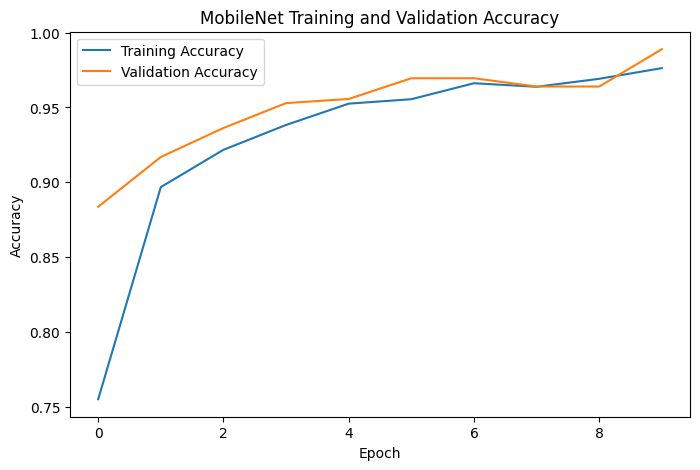

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNet Training and Validation Accuracy")
plt.legend()
plt.show()

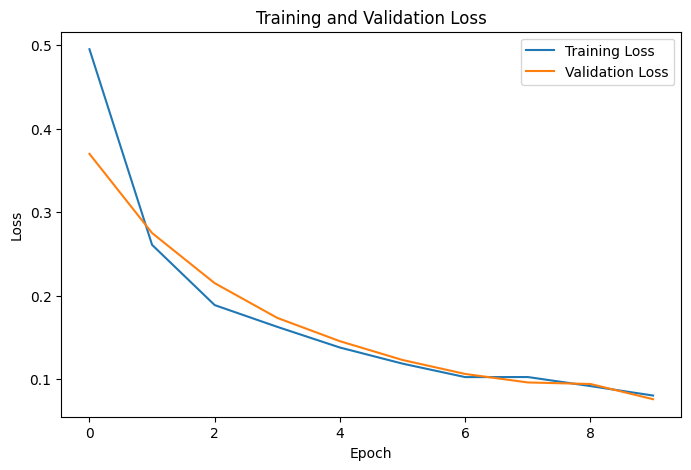

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
test_results = model.evaluate(
    test_generator,
    return_dict=True
)

print("\nTEST RESULTS")
for name, value in test_results.items():
    print(f"{name}: {value:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 393ms/step - accuracy: 0.9725 - loss: 0.0852 - precision: 0.9800 - recall: 0.9545

TEST RESULTS
accuracy: 0.9725
loss: 0.0852
precision: 0.9800
recall: 0.9545


In [ ]:
import numpy as np

y_true = []
y_probabilities = []

for images, labels in test_ds:

    logits = model.predict(
        images,
        verbose=0
    )

    probabilities = tf.nn.softmax(logits, axis=1)

    y_true.extend(labels.numpy())
    y_probabilities.extend(probabilities.numpy())

y_true = np.array(y_true)
y_probabilities = np.array(y_probabilities)

y_pred = np.argmax(
    y_probabilities,
    axis=1
)

print("Predictions generated successfully.")
print("Number of test images:", len(y_true))

Predictions generated successfully.
Number of test images: 364


In [ ]:
test_generator.reset()

y_probabilities = model.predict(
    test_generator,
    verbose=1
).ravel()

print("Number of predictions:", len(y_probabilities))

print("\nFirst 20 probabilities:")
print(y_probabilities[:20])

print("\nProbability statistics:")
print("Minimum :", y_probabilities.min())
print("Maximum :", y_probabilities.max())
print("Mean    :", y_probabilities.mean())

print("\nPredictions >= 0.5:",
      np.sum(y_probabilities >= 0.5))

print("Predictions < 0.5:",
      np.sum(y_probabilities < 0.5))

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 482ms/step
Number of predictions: 364

First 20 probabilities:
[0.08646739 0.30988094 0.0217602  0.02806237 0.04292842 0.00589741
 0.00080024 0.01232835 0.01892272 0.0061353  0.01454393 0.01310063
 0.01253209 0.01149315 0.02557248 0.53169835 0.11795149 0.07933316
 0.00939054 0.03448928]

Probability statistics:
Minimum : 0.00056697486
Maximum : 0.99999845
Mean    : 0.4174714

Predictions >= 0.5: 150
Predictions < 0.5: 214


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step
Class mapping:
{'Normal Stitches': 0, 'broken stitches': 1}

True label counts:
[210 154]

Predicted label counts:
[214 150]

Evaluation Results
Accuracy : 0.9725
Precision: 0.9800
Recall   : 0.9545
F1 Score : 0.9671

Classification Report:

                 precision    recall  f1-score   support

Normal Stitches       0.97      0.99      0.98       210
broken stitches       0.98      0.95      0.97       154

       accuracy                           0.97       364
      macro avg       0.97      0.97      0.97       364
   weighted avg       0.97      0.97      0.97       364


Confusion Matrix:
[[207   3]
 [  7 147]]


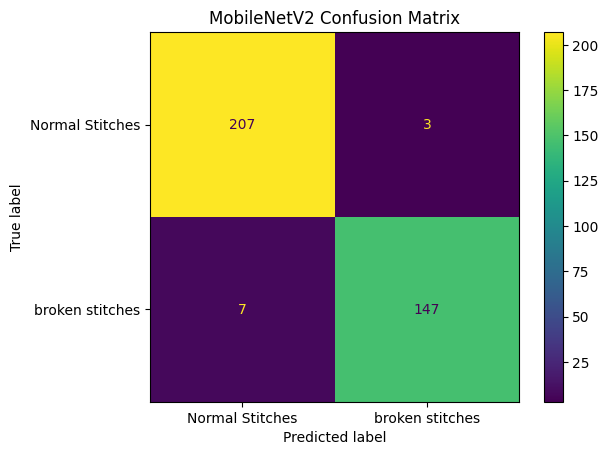

In [ ]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt

# ============================================================
# Reset generator
# ============================================================

test_generator.reset()

# ============================================================
# Generate probabilities
# ============================================================

y_prob = model.predict(
    test_generator,
    verbose=1
).ravel()

# ============================================================
# True labels
# ============================================================

y_true = test_generator.classes

# ============================================================
# Convert probabilities to class predictions
# 0 = Normal Stitches
# 1 = broken stitches
# ============================================================

y_pred = (y_prob >= 0.5).astype(int)

# ============================================================
# Verify
# ============================================================

print("Class mapping:")
print(test_generator.class_indices)

print("\nTrue label counts:")
print(np.bincount(y_true))

print("\nPredicted label counts:")
print(np.bincount(y_pred))

# ============================================================
# Metrics
# ============================================================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nEvaluation Results")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Normal Stitches",
            "broken stitches"
        ]
    )
)

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal Stitches",
        "broken stitches"
    ]
)

disp.plot()
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

In [ ]:
# CELL 24 — Save the trained  model

mobileNet_model_path = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/mobileNet_Model.keras"

model.save(mobileNet_model_path)

print("model saved successfully.")
print("Location:", mobileNet_model_path)

model saved successfully.
Location: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/mobileNet_Model.keras
